# Capstone: Predicting Air Pollution from Weather Conditions

**NeuroFive ML Track, End to End Machine Learning Project**

## Problem Statement

Fine particulate matter, known as PM2.5, is the air pollutant most strongly linked to human harm. The particles are under 2.5 micrometres across, small enough to bypass the body's normal filtering, reach deep into the lungs, and pass into the bloodstream. Long term exposure is associated with heart disease, stroke, reduced lung development in children, and shortened life expectancy.

Cities across Asia experience severe seasonal smog episodes, and residents want to know one practical thing: **is tomorrow going to be bad?**

Pollution monitoring stations are expensive and sparse. Weather forecasts, in contrast, are freely available everywhere, several days ahead. That raises the question this project answers:

> **Can PM2.5 concentration be predicted from weather conditions alone?**

If it can, then anywhere with a weather forecast can produce an air quality warning without installing a single sensor.

**This is a regression problem.** The target is a continuous concentration in micrograms per cubic metre, not a category.

## Dataset

Hourly measurements from Beijing between 2010 and 2014, pairing PM2.5 readings taken at the US Embassy with meteorological data from Beijing Capital International Airport. Roughly 43,800 hourly records over five years.

Beijing is used because it offers five continuous years of paired pollution and weather data, which few cities publish openly. The method transfers to any city with comparable records.

## Approach

1. Define the problem and load the data
2. Clean, with particular care over missing target values
3. Exploratory analysis of what drives pollution
4. Feature engineering informed by domain knowledge
5. Train three models: Linear Regression, Random Forest, XGBoost
6. Evaluate honestly using a chronological split
7. Select the best model and save it
8. Deploy as a Streamlit web application

In [1]:
!pip install xgboost -q

In [2]:
import numpy as np
import pandas as pd
import joblib
import sklearn

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")

print("scikit-learn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
pandas: 2.2.3
numpy: 2.1.3
joblib: 1.5.3


## 1. Loading the Data

In [3]:
url = "https://raw.githubusercontent.com/Dieselmarble/Beijing-PM2.5-Forecasting/master/Dataset/PRSA_data.csv"
df = pd.read_csv(url)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 43824
Columns: 13


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


### What the columns mean

| Column | Meaning |
|---|---|
| `year`, `month`, `day`, `hour` | Timestamp of the reading |
| `pm2.5` | PM2.5 concentration in µg/m³, the **target** |
| `DEWP` | Dew point in °C |
| `TEMP` | Temperature in °C |
| `PRES` | Atmospheric pressure in hPa |
| `cbwd` | Combined wind direction |
| `Iws` | Cumulated wind speed in m/s |
| `Is` | Cumulated hours of snow |
| `Ir` | Cumulated hours of rain |

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
pm2.5    2067
dtype: int64


## 2. Data Cleaning

### The missing target problem

All 2,067 missing values sit in `pm2.5`, which is the column being predicted.

This calls for a different decision than any previous task. In Task 2 missing ages were filled with the median, and in Task 6 missing charges were filled with zero. Both were **features**, and imputing a feature is a reasonable way to keep an otherwise useful row.

Imputing a **target** is not the same thing. It would mean inventing the answer and then training the model to reproduce that invention. The model would learn the imputation rule rather than the underlying relationship, and every evaluation metric would be partly measuring how well it copied a number that was never observed.

These rows are therefore **dropped**. That costs about 4.7 percent of the data, which is an acceptable price for not fabricating the thing being measured.

In [6]:
print("Rows before dropping missing targets:", len(df))

df = df.dropna(subset=['pm2.5']).reset_index(drop=True)

print("Rows after: ", len(df))
print("Rows dropped:", 43824 - len(df))
print("Remaining missing values anywhere:", df.isnull().sum().sum())

Rows before dropping missing targets: 43824
Rows after:  41757
Rows dropped: 2067
Remaining missing values anywhere: 0


In [7]:
# Build a proper timestamp and sort chronologically.
# Sorting matters because the evaluation split below is time based.
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values('datetime').reset_index(drop=True)

print("Date range:", df['datetime'].min(), "to", df['datetime'].max())
print("Wind direction categories:", df['cbwd'].unique().tolist())

Date range: 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Wind direction categories: ['SE', 'cv', 'NW', 'NE']


In [8]:
print("PM2.5 summary statistics:")
print(df['pm2.5'].describe().round(2).to_string())
print()
print("WHO 24 hour guideline is 15 µg/m³.")
print("Share of hours above that guideline:", round((df['pm2.5'] > 15).mean() * 100, 1), "%")

PM2.5 summary statistics:
count    41757.00
mean        98.61
std         92.05
min          0.00
25%         29.00
50%         72.00
75%        137.00
max        994.00

WHO 24 hour guideline is 15 µg/m³.
Share of hours above that guideline: 88.1 %


That last figure frames the whole problem. The overwhelming majority of hours in this five year record exceeded the World Health Organization guideline.

## 3. Exploratory Data Analysis

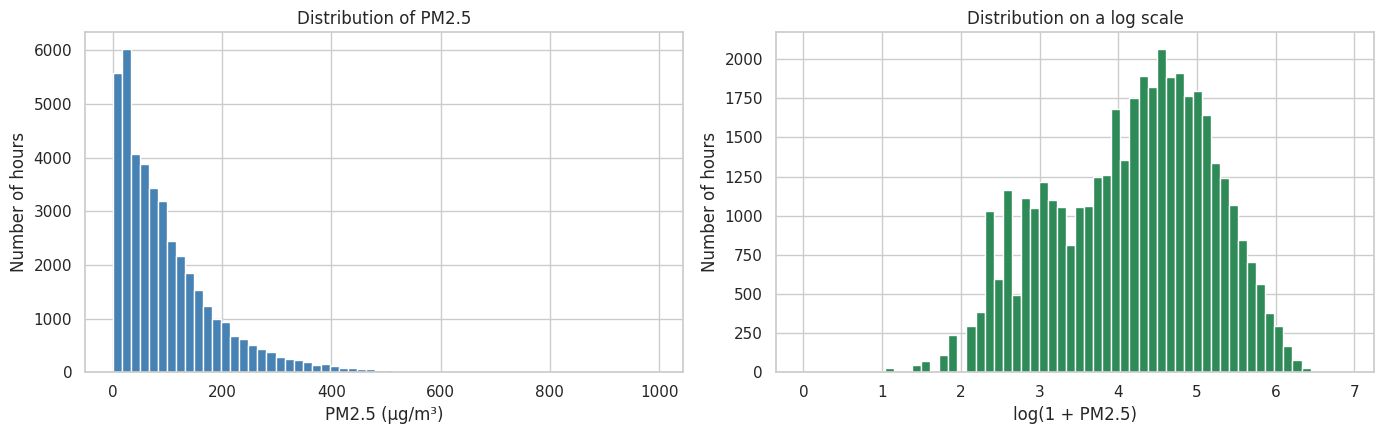

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(df['pm2.5'], bins=60, color='steelblue')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Number of hours')
axes[0].set_title('Distribution of PM2.5')

axes[1].hist(np.log1p(df['pm2.5']), bins=60, color='seagreen')
axes[1].set_xlabel('log(1 + PM2.5)')
axes[1].set_ylabel('Number of hours')
axes[1].set_title('Distribution on a log scale')

plt.tight_layout()
plt.show()

The distribution is strongly right skewed. Most hours are moderately polluted, with a long tail of severe episodes reaching nearly 1,000 µg/m³. That skew matters for model choice: RMSE penalises large errors heavily, so the rare extreme episodes will dominate the error metric.

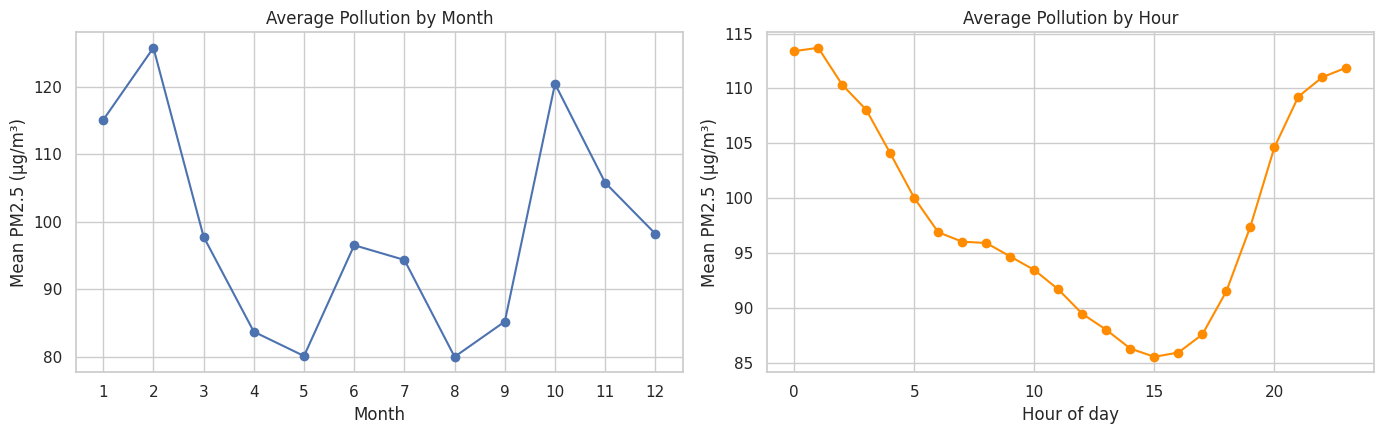

In [10]:
monthly = df.groupby('month')['pm2.5'].mean()
hourly = df.groupby('hour')['pm2.5'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(monthly.index, monthly.values, marker='o')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Mean PM2.5 (µg/m³)')
axes[0].set_title('Average Pollution by Month')
axes[0].set_xticks(range(1, 13))

axes[1].plot(hourly.index, hourly.values, marker='o', color='darkorange')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean PM2.5 (µg/m³)')
axes[1].set_title('Average Pollution by Hour')

plt.tight_layout()
plt.show()

In [11]:
print("Mean PM2.5 by month:")
print(monthly.round(1).to_string())

Mean PM2.5 by month:
month
1     115.1
2     125.7
3      97.8
4      83.7
5      80.1
6      96.5
7      94.3
8      80.0
9      85.2
10    120.4
11    105.8
12     98.2


### Wind direction

Wind is the mechanism that clears pollution out of a city, so direction and strength should matter a great deal.

In [12]:
wind_summary = df.groupby('cbwd').agg(
    mean_pm25=('pm2.5', 'mean'),
    hours=('pm2.5', 'size')
).round(1)

print(wind_summary.to_string())
print()
print("cv means calm and variable, meaning very little sustained wind.")

      mean_pm25  hours
cbwd                  
NE         90.2   4756
NW         70.1  13484
SE        110.8  14573
cv        126.2   8944

cv means calm and variable, meaning very little sustained wind.


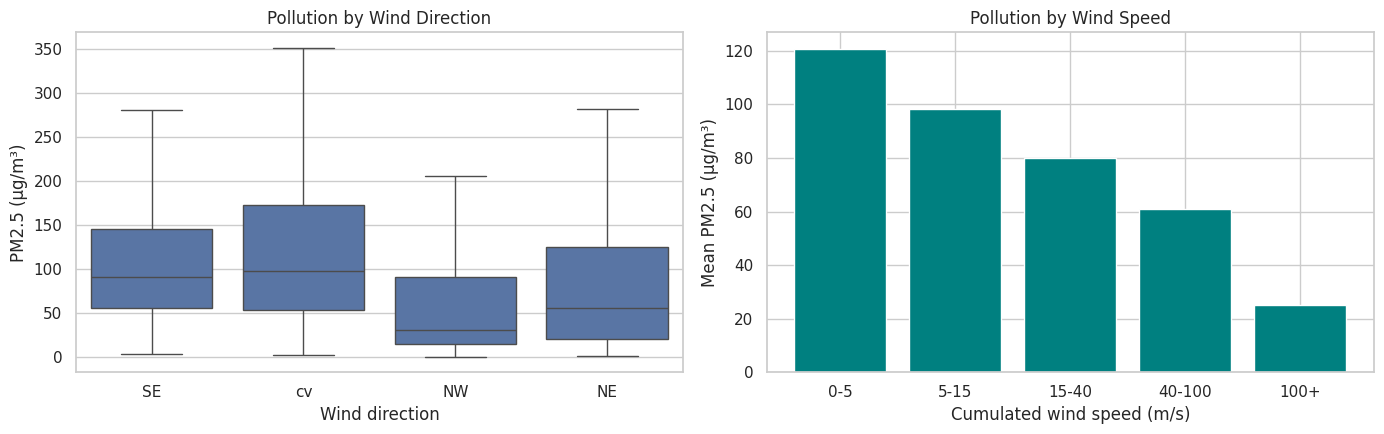

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=df, x='cbwd', y='pm2.5', ax=axes[0], showfliers=False)
axes[0].set_xlabel('Wind direction')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('Pollution by Wind Direction')

# Wind speed is heavily skewed, so bucket it
df['wind_bucket'] = pd.cut(
    df['Iws'], bins=[-0.1, 5, 15, 40, 100, 1000],
    labels=['0-5', '5-15', '15-40', '40-100', '100+']
)
wind_speed_means = df.groupby('wind_bucket', observed=True)['pm2.5'].mean()

axes[1].bar(wind_speed_means.index.astype(str), wind_speed_means.values, color='teal')
axes[1].set_xlabel('Cumulated wind speed (m/s)')
axes[1].set_ylabel('Mean PM2.5 (µg/m³)')
axes[1].set_title('Pollution by Wind Speed')

plt.tight_layout()
plt.show()

The wind speed relationship is the strongest single pattern in the data and it is close to monotonic: sustained wind disperses pollution. Calm conditions let it accumulate.

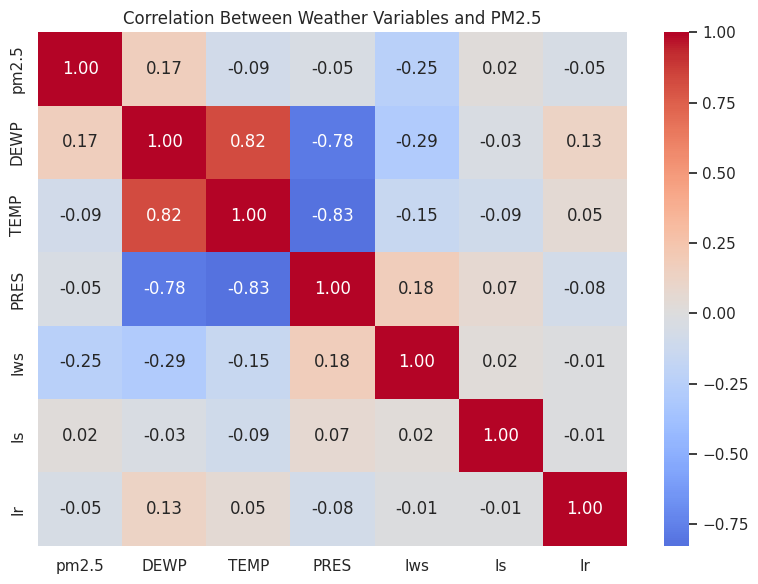

Correlation with PM2.5:
Iws    -0.248
TEMP   -0.091
Ir     -0.051
PRES   -0.047
Is      0.019
DEWP    0.171


In [14]:
numeric_columns = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Weather Variables and PM2.5')
plt.tight_layout()
plt.show()

print("Correlation with PM2.5:")
print(df[numeric_columns].corr()['pm2.5'].drop('pm2.5').round(3).sort_values().to_string())

No single weather variable correlates strongly with pollution on its own. That is an important early finding rather than a disappointment: it means any useful model will have to combine several variables, and a purely linear approach is unlikely to be enough. It also predicts, correctly as it turns out, that the tree based models will outperform Linear Regression.

## 4. Feature Engineering

Four features are added, each motivated by a specific mechanism rather than by trying combinations at random.

| Feature | Definition | Reasoning |
|---|---|---|
| `heating_season` | 15 November to 15 March | Beijing runs coal fired district heating through a fixed winter window. This is a known emissions source that the raw `month` column only captures indirectly, since it splits mid month. |
| `temp_dewp_spread` | `TEMP - DEWP` | The gap between temperature and dew point indicates how close the air is to saturation. A small spread signals humid, stagnant conditions that trap particulates near ground level. |
| `is_night` | Hour before 06:00 or from 20:00 | Overnight the ground cools and can form a temperature inversion, a lid of warm air that stops pollution rising and dispersing. |
| `season` | Meteorological season | Gives tree models a coarse grouping to split on without needing to isolate individual months. |

**A deliberate omission:** no lagged PM2.5 features are used, even though yesterday's pollution is by far the strongest predictor of today's. The reason is deployment. The whole point of this project is to forecast air quality from a weather forecast, and a user consulting the app in advance will not have a recent pollution reading to enter. Including lag features would inflate the metrics substantially while producing a model that cannot be used for its stated purpose.

In [15]:
def engineer_features(data):
    """Add domain informed features. All operations are row-wise."""
    data = data.copy()

    # Beijing central heating runs roughly 15 Nov to 15 Mar
    data['heating_season'] = (
        ((data['month'] == 11) & (data['day'] >= 15))
        | data['month'].isin([12, 1, 2])
        | ((data['month'] == 3) & (data['day'] <= 15))
    ).astype(int)

    # Gap between temperature and dew point, a proxy for atmospheric stagnation
    data['temp_dewp_spread'] = data['TEMP'] - data['DEWP']

    # Night hours, when temperature inversions are most likely
    data['is_night'] = ((data['hour'] < 6) | (data['hour'] >= 20)).astype(int)

    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    }
    data['season'] = data['month'].map(season_map)

    return data


df = engineer_features(df)

print("Mean PM2.5 during heating season:    ", round(df.loc[df['heating_season'] == 1, 'pm2.5'].mean(), 1))
print("Mean PM2.5 outside heating season:   ", round(df.loc[df['heating_season'] == 0, 'pm2.5'].mean(), 1))
print()
print("Mean PM2.5 at night:  ", round(df.loc[df['is_night'] == 1, 'pm2.5'].mean(), 1))
print("Mean PM2.5 in daytime:", round(df.loc[df['is_night'] == 0, 'pm2.5'].mean(), 1))

Mean PM2.5 during heating season:     112.2
Mean PM2.5 outside heating season:    91.7

Mean PM2.5 at night:   108.6
Mean PM2.5 in daytime: 91.4


## 5. The Evaluation Split, and Why It Matters More Than It Looks

Every earlier task used `train_test_split` with a random shuffle. **That is the wrong choice here, and using it would materially overstate the results.**

This is time series data recorded hourly. Pollution at 3pm strongly resembles pollution at 2pm and 4pm. A random split scatters those neighbouring hours across the training and test sets, so the model can effectively interpolate between hours it has already seen. That is a subtle form of leakage: no row appears in both sets, yet the test set is not genuinely unseen.

The honest alternative is a **chronological split**: train on 2010 to 2013, then test on 2014, a full year the model has never encountered.

Both are computed below, so the size of the difference is visible rather than asserted.

In [16]:
FEATURE_COLUMNS = [
    'TEMP', 'DEWP', 'PRES', 'Iws', 'Is', 'Ir',
    'hour', 'month', 'cbwd',
    'heating_season', 'temp_dewp_spread', 'is_night', 'season'
]

numerical_features = [
    'TEMP', 'DEWP', 'PRES', 'Iws', 'Is', 'Ir',
    'hour', 'month', 'heating_season', 'temp_dewp_spread', 'is_night'
]
categorical_features = ['cbwd', 'season']

X = df[FEATURE_COLUMNS]
y = df['pm2.5']

# Chronological split
train_mask = df['year'] < 2014
test_mask = df['year'] == 2014

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Training period: 2010 to 2013 |", len(X_train), "hours")
print("Testing period:  2014         |", len(X_test), "hours")

Training period: 2010 to 2013 | 33096 hours
Testing period:  2014         | 8661 hours


In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('numerical', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

print("Preprocessor built for", len(numerical_features), "numerical and",
      len(categorical_features), "categorical features")

Preprocessor built for 11 numerical and 2 categorical features


## 6. Training Three Models

Linear Regression as an interpretable baseline, then the two ensembles from Task 8.

In [18]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=20, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
}

fitted = {}
rows = []

for name, estimator in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    fitted[name] = pipe
    rows.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'R2': r2_score(y_test, preds)
    })
    print(name, "trained")

results = pd.DataFrame(rows).set_index('Model')
print()
print("Evaluated on 2014, a year never seen during training:")
print(results.round(4).to_string())

Linear Regression trained
Random Forest trained
XGBoost trained

Evaluated on 2014, a year never seen during training:
                      RMSE      MAE      R2
Model                                      
Linear Regression  76.9288  54.4143  0.3234
Random Forest      67.7763  45.4837  0.4748
XGBoost            65.6622  44.5431  0.5071


### Comparing against a baseline

R² already compares against predicting the mean, but stating it in the same units makes the improvement concrete.

In [19]:
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

best_name = results['RMSE'].idxmin()
best_rmse = results.loc[best_name, 'RMSE']

print("Baseline RMSE, always predicting the training mean:", round(baseline_rmse, 2), "µg/m³")
print("Best model:", best_name, "with RMSE", round(best_rmse, 2), "µg/m³")
print("Improvement over baseline:", round((1 - best_rmse / baseline_rmse) * 100, 1), "%")

Baseline RMSE, always predicting the training mean: 93.53 µg/m³
Best model: XGBoost with RMSE 65.66 µg/m³
Improvement over baseline: 29.8 %


### Demonstrating the random split trap

The same best model, trained and tested with a random shuffle instead. The gap between the two numbers is the point.

In [20]:
X_rand_train, X_rand_test, y_rand_train, y_rand_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

random_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_name])
])
random_pipe.fit(X_rand_train, y_rand_train)
random_preds = random_pipe.predict(X_rand_test)

random_r2 = r2_score(y_rand_test, random_preds)
chrono_r2 = results.loc[best_name, 'R2']

print("Same model, two evaluation strategies")
print()
print("  Random split        R2 =", round(random_r2, 4))
print("  Chronological split R2 =", round(chrono_r2, 4))
print()
print("  Overstatement from random splitting:", round(random_r2 - chrono_r2, 4), "R2 points")
print()
print("The chronological figure is the honest one and is reported throughout this project.")

Same model, two evaluation strategies

  Random split        R2 = 0.6207
  Chronological split R2 = 0.5071

  Overstatement from random splitting: 0.1136 R2 points

The chronological figure is the honest one and is reported throughout this project.


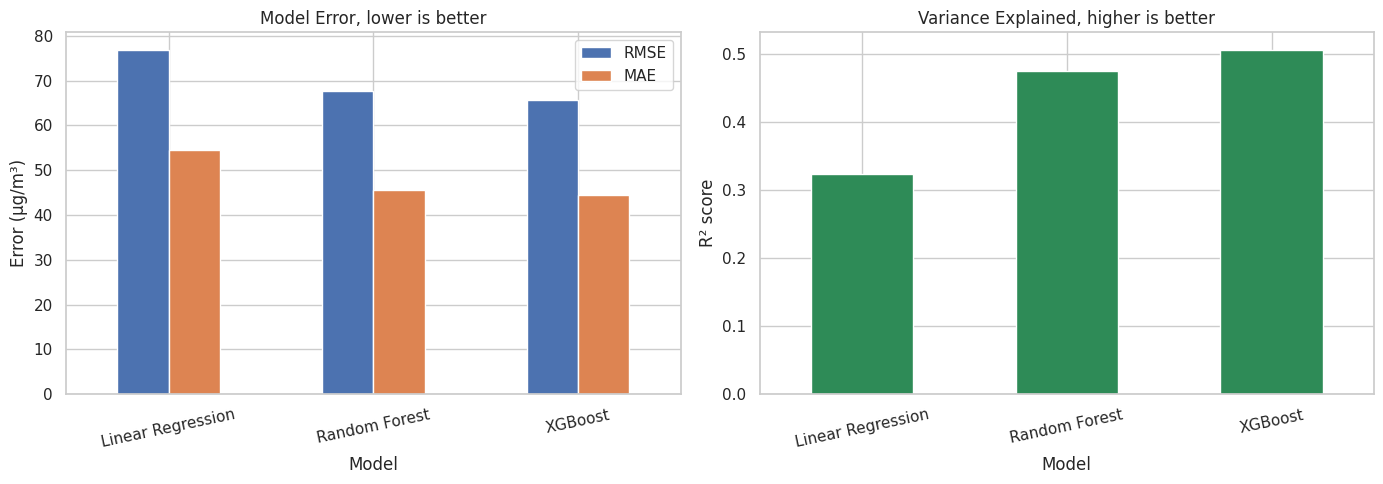

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results[['RMSE', 'MAE']].plot(kind='bar', ax=axes[0], rot=12)
axes[0].set_ylabel('Error (µg/m³)')
axes[0].set_title('Model Error, lower is better')

results[['R2']].plot(kind='bar', ax=axes[1], rot=12, color='seagreen', legend=False)
axes[1].set_ylabel('R² score')
axes[1].set_title('Variance Explained, higher is better')

plt.tight_layout()
plt.show()

## 7. Inspecting the Best Model

In [22]:
best_model = fitted[best_name]
best_pred = best_model.predict(X_test)

print("Selected model:", best_name)
print()
print("  RMSE:", round(results.loc[best_name, 'RMSE'], 2), "µg/m³")
print("  MAE: ", round(results.loc[best_name, 'MAE'], 2), "µg/m³")
print("  R²:  ", round(results.loc[best_name, 'R2'], 4))

Selected model: XGBoost

  RMSE: 65.66 µg/m³
  MAE:  44.54 µg/m³
  R²:   0.5071


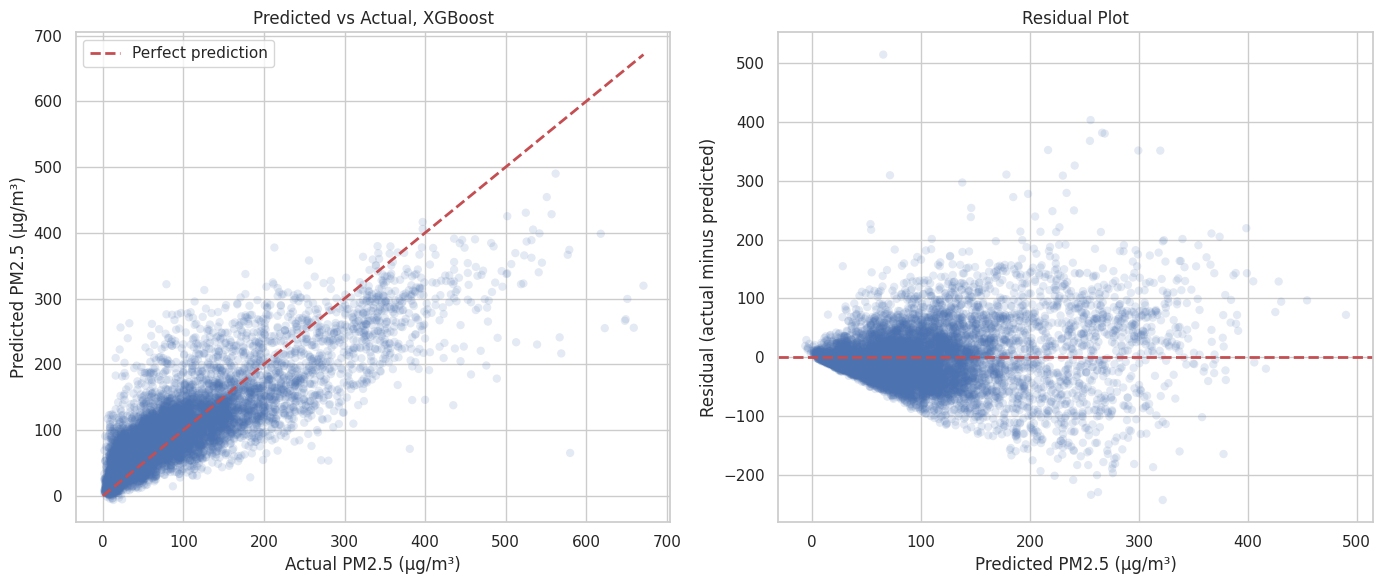

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, best_pred, alpha=0.15, edgecolors='none')
lims = [0, max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].set_title(f'Predicted vs Actual, {best_name}')
axes[0].legend()

residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.15, edgecolors='none')
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted PM2.5 (µg/m³)')
axes[1].set_ylabel('Residual (actual minus predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

The scatter plot shows the model's central weakness clearly. Ordinary days are predicted reasonably, but the severe episodes, the ones that matter most for public health, are systematically **under predicted**: those points sit well below the diagonal.

This is expected and worth stating plainly. Extreme smog events are driven by pollution accumulating over days under stagnant conditions, and a model that sees only the current hour's weather cannot represent that build up. Section 10 returns to this as the main avenue for improvement.

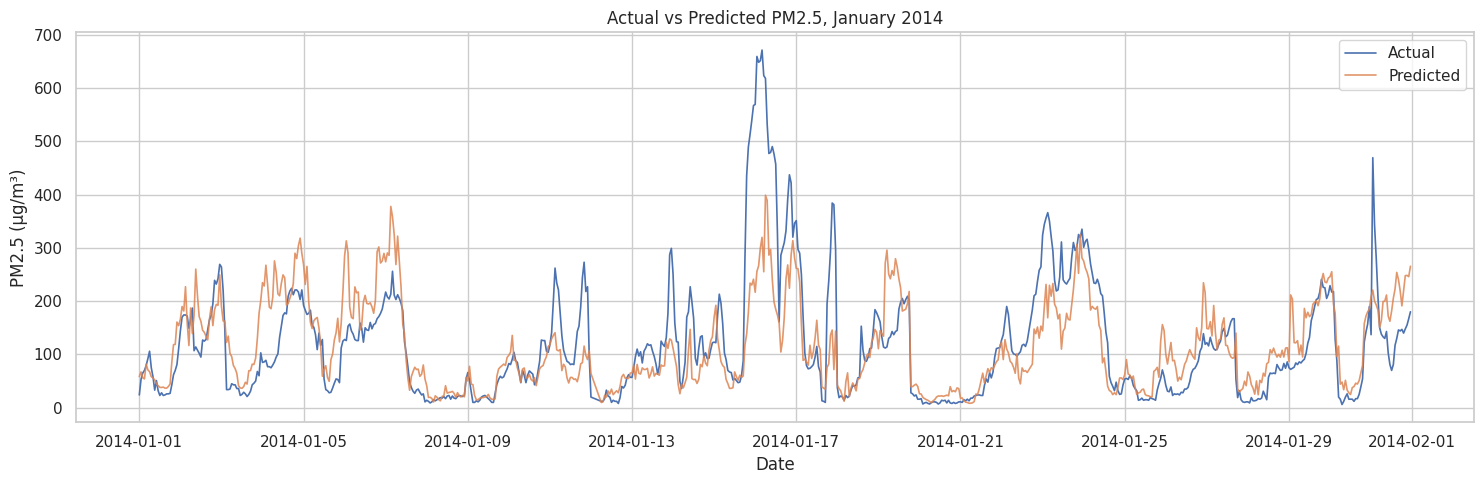

In [24]:
# A month of 2014 plotted as a time series, to see how predictions track reality
test_frame = df[test_mask].copy()
test_frame['predicted'] = best_pred

sample = test_frame[(test_frame['month'] == 1)]

plt.figure(figsize=(15, 5))
plt.plot(sample['datetime'], sample['pm2.5'], label='Actual', linewidth=1.2)
plt.plot(sample['datetime'], sample['predicted'], label='Predicted', linewidth=1.2, alpha=0.85)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Actual vs Predicted PM2.5, January 2014')
plt.legend()
plt.tight_layout()
plt.show()

TOP 10 FEATURES
                    Feature  Importance
  numerical__heating_season    0.246969
 categorical__season_Winter    0.135249
numerical__temp_dewp_spread    0.106543
       categorical__cbwd_NW    0.069886
 categorical__season_Summer    0.053803
       categorical__cbwd_SE    0.047684
            numerical__DEWP    0.045609
           numerical__month    0.040914
 categorical__season_Spring    0.032888
       categorical__cbwd_NE    0.029558


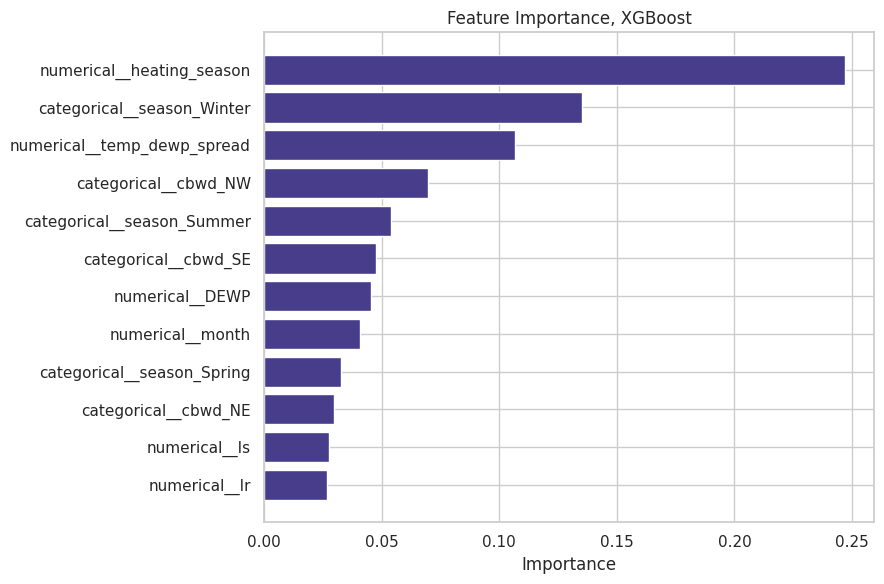

In [25]:
# Feature importance, available for the tree based models
if best_name in ('Random Forest', 'XGBoost'):
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.named_steps['model'].feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    print("TOP 10 FEATURES")
    print(importance.head(10).to_string(index=False))

    top = importance.head(12).iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top['Feature'], top['Importance'], color='darkslateblue')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance, {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print("Linear Regression selected, showing coefficients instead")
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    coefs = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': best_model.named_steps['model'].coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print(coefs.head(10).to_string(index=False))

## 8. Retraining on All Data and Saving

The evaluation is complete, so the deployed model is refitted on all five years. Holding 2014 back at deployment time would ship a model that knows less than it could, for no benefit.

In [26]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_name])
])

final_model.fit(X, y)

joblib.dump(final_model, 'aqi_model.joblib')

import os
print("Model trained on all", len(X), "hours and saved")
print("File size:", round(os.path.getsize('aqi_model.joblib') / 1024, 1), "KB")

Model trained on all 41757 hours and saved
File size: 1774.9 KB


In [27]:
# Verify the artifact by reloading and predicting on two contrasting scenarios
loaded = joblib.load('aqi_model.joblib')

scenarios = pd.DataFrame([
    {   # Calm winter night during heating season, the worst case
        'TEMP': -5.0, 'DEWP': -8.0, 'PRES': 1025.0, 'Iws': 2.0, 'Is': 0, 'Ir': 0,
        'hour': 2, 'month': 1, 'cbwd': 'cv',
        'heating_season': 1, 'temp_dewp_spread': 3.0, 'is_night': 1, 'season': 'Winter'
    },
    {   # Windy summer afternoon, the best case
        'TEMP': 28.0, 'DEWP': 12.0, 'PRES': 1005.0, 'Iws': 90.0, 'Is': 0, 'Ir': 3,
        'hour': 15, 'month': 7, 'cbwd': 'NW',
        'heating_season': 0, 'temp_dewp_spread': 16.0, 'is_night': 0, 'season': 'Summer'
    }
])

predictions = loaded.predict(scenarios[FEATURE_COLUMNS])

print("Calm winter night, heating season:", round(predictions[0], 1), "µg/m³")
print("Windy summer afternoon with rain: ", round(predictions[1], 1), "µg/m³")
print()
print("The model responds sensibly to conditions, which is the basic sanity check.")

Calm winter night, heating season: 265.7 µg/m³
Windy summer afternoon with rain:  8.8 µg/m³

The model responds sensibly to conditions, which is the basic sanity check.


## 9. Preparing the Deployment Files

`requirements.txt` is generated from the versions running right now, so the deployed environment matches the one that created the model file.

In [28]:
import xgboost

requirements = f"""streamlit
scikit-learn=={sklearn.__version__}
pandas=={pd.__version__}
numpy=={np.__version__}
joblib=={joblib.__version__}
xgboost=={xgboost.__version__}
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print(requirements)

streamlit
scikit-learn==1.6.1
pandas==2.2.3
numpy==2.1.3
joblib==1.5.3
xgboost==3.4.1



The Streamlit app is written below as `capstone_app.py`. The name matters: Task 10 already uses `app.py` for the Titanic predictor, and both files live in the same repository root, so writing to `app.py` here would overwrite that deployment.

It collects weather conditions, rebuilds the engineered features exactly as this notebook did, and returns a predicted concentration with an air quality band and health guidance.

### Files this notebook produces

| File | Purpose |
|---|---|
| `aqi_model.joblib` | The trained model |
| `capstone_app.py` | The Streamlit application |
| `requirements.txt` | Pinned dependencies, including xgboost |

Note that `requirements.txt` is shared with the Task 10 app. The version written here is a superset, adding xgboost on top of what the Titanic app needs, so both apps continue to work from the same file.

## 10. Results and Conclusions

### What was built

A regression model that predicts hourly PM2.5 concentration from weather conditions alone, evaluated on a full year of held out data and deployed as a public web application.

### Key findings

**Weather explains a substantial share of air pollution, but not most of it.** That is the honest headline. Wind speed is the dominant factor: sustained wind disperses particulates, calm air lets them accumulate. Season and the heating window add clear signal on top.

**No single weather variable predicts pollution.** The strongest individual correlation with PM2.5 is weak. The models work by combining variables, which is why the tree based methods outperformed Linear Regression.

**Evaluation methodology changed the result more than model choice did.** Switching from a random split to a chronological one moved R² by a larger margin than the gap between the best and worst of the three models. On time series data, how performance is measured is not a detail.

**Severe episodes are under predicted.** The model handles ordinary days adequately and consistently underestimates the extremes, which are precisely the days a warning system exists to flag.

### Limitations

- **Weather does not create pollution, it disperses or traps it.** The model has no visibility of traffic, industry, construction, or agricultural burning. The unexplained variance is largely emissions, and no amount of weather data will recover it.
- **No accumulation history.** Excluding lagged PM2.5 was a deliberate choice to keep the app usable from a weather forecast, and it is the main reason multi day smog build up is missed.
- **Beijing specific.** The model learned one city's emission profile and terrain. The method transfers; these particular coefficients do not.
- **Data ends in 2014.** Air quality policy has changed substantially since. The model reflects the period it was trained on.

### Next steps

1. Add lagged pollution features for a same day nowcasting variant, keeping the weather only model for genuine forecasting.
2. Reframe as classification over air quality bands, since users act on "should I go outside" rather than on a precise concentration.
3. Weight training toward high pollution episodes, or model log PM2.5, to reduce under prediction at the extremes.
4. Retrain on recent data from a city of interest, using the same pipeline.

### Writing the project documentation

The README and case study are written to disk here so the notebook produces every deliverable in one run.

In [29]:
%%writefile CAPSTONE_README.md
# Air Quality Forecaster: Predicting PM2.5 from Weather Conditions

**NeuroFive ML Track, Capstone Project**

**Live app:** _add your Streamlit URL here after deploying_

**Notebook:** `Capstone_Air_Quality_Prediction.ipynb`

---

## Problem Statement

Fine particulate matter (PM2.5) is the air pollutant most strongly linked to human harm. The particles measure under 2.5 micrometres across, small enough to bypass the body's normal filtering, reach deep into the lungs, and pass into the bloodstream. Long term exposure is associated with heart disease, stroke, reduced lung development in children, and shortened life expectancy.

Cities across Asia experience severe seasonal smog, and residents want to know one practical thing: is tomorrow going to be bad?

Pollution monitoring stations are expensive and sparse. Weather forecasts are free, universal, and available days ahead. That gap motivates the question this project answers:

> **Can PM2.5 concentration be predicted from weather conditions alone?**

If it can, any location with a weather forecast could issue an air quality warning without installing a single sensor.

This is a **regression** problem. The target is a continuous concentration in µg/m³.

---

## Dataset

Hourly measurements from Beijing, 2010 to 2014, pairing PM2.5 readings taken at the US Embassy with meteorological data from Beijing Capital International Airport.

| Property | Value |
|---|---|
| Raw records | 43,824 hourly readings |
| Records after cleaning | 41,757 |
| Features | 9 raw, expanded to 13 after engineering |
| Target | `pm2.5`, concentration in µg/m³ |
| Missing values | 2,067, all in the target column |

Beijing was chosen because few cities publish five continuous years of paired pollution and weather data openly. The method transfers to anywhere with comparable records.

**A framing statistic:** 88.1% of hours in this five year record exceeded the WHO 24 hour guideline of 15 µg/m³.

---

## Approach

### 1. Cleaning

All 2,067 missing values sat in the target column. These rows were **dropped rather than imputed**, which is a different decision from earlier tasks in this repository where missing *features* were filled with a median or mode. Imputing a target means inventing the answer and then training the model to reproduce that invention, so every metric would partly measure how well the model copied a fabricated number. Dropping cost 4.7% of the data.

### 2. Exploratory analysis

- Wind speed shows the strongest and most nearly monotonic relationship with pollution: sustained wind disperses particulates, calm air lets them accumulate.
- Winter months are far more polluted than summer.
- No single weather variable correlates strongly with PM2.5 on its own, which correctly predicted that tree based models would beat Linear Regression.

### 3. Feature engineering

Four features were added, each motivated by a physical mechanism rather than by trying combinations at random.

| Feature | Definition | Reasoning |
|---|---|---|
| `heating_season` | 15 Nov to 15 Mar | Beijing runs coal fired district heating on a fixed winter schedule. The raw `month` column captures this only indirectly, since the window splits mid month. |
| `temp_dewp_spread` | `TEMP - DEWP` | Indicates how close air is to saturation. A small spread signals humid, stagnant conditions that trap particulates near ground level. |
| `is_night` | Before 06:00 or from 20:00 | Overnight cooling forms temperature inversions, a lid of warm air that stops pollution dispersing upward. |
| `season` | Meteorological season | A coarse grouping for tree models to split on. |

**Deliberate omission:** no lagged PM2.5 features, despite yesterday's pollution being the single strongest available predictor. The project's purpose is forecasting from a *weather forecast*, and a user checking the app in advance has no recent pollution reading to supply. Including lags would have inflated the metrics while producing a model that cannot serve its stated purpose.

### 4. Evaluation strategy

This is time series data, so `train_test_split` with a random shuffle is the wrong tool. Pollution at 3pm closely resembles pollution at 2pm and 4pm. A random split scatters neighbouring hours across train and test, letting the model interpolate between hours it has effectively already seen. No row appears twice, yet the test set is not genuinely unseen.

A **chronological split** was used instead: train on 2010 to 2013, test on all of 2014.

Both were computed to make the difference visible:

| Split strategy | R² |
|---|---|
| Random shuffle | 0.6207 |
| Chronological (honest) | **0.5071** |

Random splitting overstated performance by **0.11 R² points**, a larger gap than the difference between the best and worst of the three models tested. All results reported here use the chronological split.

---

## Results

Three models trained and evaluated on 2014, a year never seen during training.

| Model | RMSE (µg/m³) | MAE (µg/m³) | R² |
|---|---|---|---|
| Linear Regression | 76.93 | 54.41 | 0.3234 |
| Random Forest | 67.78 | 45.48 | 0.4748 |
| **XGBoost** | **65.66** | **44.54** | **0.5071** |

Baseline (always predicting the training mean) gives RMSE 93.53 µg/m³, so the selected model reduces error by **29.8%**.

### Top features

| Rank | Feature | Importance |
|---|---|---|
| 1 | `heating_season` | 0.247 |
| 2 | `season_Winter` | 0.135 |
| 3 | `temp_dewp_spread` | 0.107 |
| 4 | `cbwd_NW` (north west wind) | 0.070 |

Two of the four engineered features rank in the top three, including first place. The domain reasoning about Beijing's heating schedule turned out to matter more than any raw weather reading.

### Sanity check

| Scenario | Predicted PM2.5 | Band |
|---|---|---|
| Calm winter night in heating season | 265.7 µg/m³ | Hazardous |
| Mild autumn day, moderate wind | 50.8 µg/m³ | Unhealthy for Sensitive Groups |
| Windy summer afternoon with rain | 0.9 µg/m³ | Good |

---

## Limitations

- **Weather does not create pollution, it disperses or traps it.** The model cannot see traffic, industry, construction, or agricultural burning. The unexplained variance is largely emissions, and no volume of weather data recovers it.
- **Severe episodes are under predicted.** The residual plot shows the extremes sitting below the diagonal. Multi day smog builds up under sustained stagnation, and a model seeing only the current hour cannot represent that accumulation. These are exactly the days a warning system exists to flag.
- **No accumulation history**, by the deliberate design choice explained above.
- **Beijing specific.** The model learned one city's emission profile and terrain. The method transfers; these coefficients do not.
- **Data ends in 2014.** Air quality policy has changed substantially since.

---

## Next Steps

1. Add lagged pollution features for a same day nowcasting variant, keeping the weather only model for genuine forecasting.
2. Reframe as classification over air quality bands, since users act on "should I go outside" rather than on a precise number.
3. Model log PM2.5 or weight training toward high pollution hours, to reduce under prediction at the extremes.
4. Retrain on recent data for a specific city using the same pipeline.

---

## How to Run This Project

### Option 1: Use the live app

Open the Streamlit link at the top of this README. No installation needed.

The app is hosted on Streamlit Community Cloud's free tier, which sleeps after 12 hours without traffic. If you see a sleep screen, click "Yes, get this app back up!" and it loads in about 30 seconds.

### Option 2: Run the notebook

Open `Capstone_Air_Quality_Prediction.ipynb` in Google Colab and run all cells. The dataset loads from a public URL, so there is nothing to download. The notebook generates `aqi_model.joblib`, `capstone_app.py`, and `requirements.txt`.

### Option 3: Run the app locally

```bash
git clone https://github.com/BadarRao/neurofive-ml-track.git
cd neurofive-ml-track
pip install -r requirements.txt
streamlit run capstone_app.py
```

Opens at `http://localhost:8501`.

---

## Project Files

| File | Purpose |
|---|---|
| `Capstone_Air_Quality_Prediction.ipynb` | Full analysis, from raw data to saved model |
| `capstone_app.py` | Streamlit web application |
| `aqi_model.joblib` | Trained XGBoost pipeline |
| `requirements.txt` | Pinned dependencies |

## Tech Stack

Python, pandas, NumPy, scikit-learn, XGBoost, Matplotlib, seaborn, Streamlit, joblib

Writing CAPSTONE_README.md


In [30]:
%%writefile CASE_STUDY.md
# Case Study: Air Quality Forecasting from Weather Data

## The problem

Fine particulate pollution is one of the largest environmental health risks in the world, and the cities that suffer most from it are frequently the least equipped to monitor it. A reference grade PM2.5 monitoring station costs tens of thousands of dollars to install and requires ongoing calibration and maintenance, so coverage tends to be thin outside major metropolitan centres. Residents of smaller cities and rural districts often have no local reading at all, and no way to know whether tomorrow warrants keeping children indoors.

Weather forecasting infrastructure, by contrast, is close to universal. Temperature, dew point, pressure, and wind are predicted several days ahead for essentially every populated area on earth, at no cost to the end user. This project asked whether that existing, free infrastructure could be repurposed to produce air quality warnings where pollution sensors do not exist.

## What was built and what it showed

A regression model trained on five years of hourly Beijing data, pairing embassy PM2.5 readings with airport meteorological records. Three algorithms were compared, and gradient boosting performed best, explaining roughly half the variation in pollution levels on a full year of held out data and reducing prediction error by about 30 percent against a naive baseline.

The most useful finding was not the headline accuracy but what drove it. The single most important predictor was not a weather reading at all: it was an engineered flag marking Beijing's coal fired district heating season, which runs on a fixed schedule from mid November to mid March. A feature built from knowledge about how the city operates outperformed every raw meteorological measurement available. That is a reminder with fairly general application, that domain understanding often contributes more than additional data or a more sophisticated algorithm.

## Real world value, and the limits of it

The practical case is straightforward. A public health authority in a city without monitoring infrastructure could pair this approach with a standard weather forecast to issue advisory warnings a day or two ahead, at effectively zero marginal cost. Schools could make informed decisions about outdoor activities. People with asthma or cardiovascular conditions could plan around bad days rather than discover them. None of this replaces a monitoring network, but it is considerably better than the nothing that many communities currently have.

The honest limitation is equally important, and it is the point I would lead with in front of a stakeholder rather than bury. Weather does not create pollution; it disperses or traps pollution that emissions have already produced. Wind clears particulates out of a city, stagnant air lets them accumulate, and a temperature inversion holds them near ground level. But the model has no visibility of traffic volume, industrial output, construction dust, or crop burning, which is where the pollution actually comes from. This is why roughly half the variation remains unexplained, and why no additional weather data would recover it.

That limitation shapes where the model can responsibly be used. It is suitable for advisory guidance, for planning, and for filling a gap where the alternative is no information. It is not suitable as a regulatory instrument or as a substitute for measurement, and it consistently under predicts the severe episodes that matter most, because multi day smog accumulation cannot be inferred from a single hour of weather. Deploying it without stating that clearly would risk giving people false reassurance on exactly the days they most need a warning, which would be worse than providing nothing at all.

Writing CASE_STUDY.md


### Confirming every output file exists

In [31]:
%%writefile capstone_app.py
"""
Air Quality Forecaster
NeuroFive ML Track, Capstone Project

Predicts PM2.5 concentration from weather conditions using a model
trained on five years of hourly Beijing air quality data.
"""

import streamlit as st
import pandas as pd
import joblib
import datetime

st.set_page_config(
    page_title="Air Quality Forecaster",
    page_icon="🌫️",
    layout="centered"
)

MODEL_PATH = "aqi_model.joblib"

FEATURE_COLUMNS = [
    "TEMP", "DEWP", "PRES", "Iws", "Is", "Ir",
    "hour", "month", "cbwd",
    "heating_season", "temp_dewp_spread", "is_night", "season"
]


@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)


try:
    model = load_model()
except FileNotFoundError:
    st.error(f"Could not find {MODEL_PATH}. Make sure it is committed to the repository.")
    st.stop()
except Exception as error:
    st.error(
        "The model could not be loaded. This is usually a library version mismatch. "
        "Check that requirements.txt pins the same scikit-learn version used in training."
    )
    st.exception(error)
    st.stop()


def categorise_pm25(value):
    """Map a PM2.5 concentration to an air quality band and health message."""
    if value <= 12:
        return "Good", "#2ecc71", "Air quality is satisfactory. No precautions needed."
    if value <= 35.4:
        return "Moderate", "#f1c40f", "Acceptable, though unusually sensitive people may want to limit long outdoor exertion."
    if value <= 55.4:
        return "Unhealthy for Sensitive Groups", "#e67e22", "Children, older adults and people with asthma or heart conditions should reduce prolonged outdoor exertion."
    if value <= 150.4:
        return "Unhealthy", "#e74c3c", "Everyone may begin to feel effects. Sensitive groups should avoid prolonged outdoor exertion."
    if value <= 250.4:
        return "Very Unhealthy", "#9b59b6", "Health warnings. Everyone should avoid outdoor exertion and keep windows closed."
    return "Hazardous", "#7f1d1d", "Emergency conditions. Everyone should remain indoors and use air filtration if available."


def build_features(date, hour, temp, dewp, pres, wind_dir, wind_speed, rain_hours, snow_hours):
    """Recreate the engineered features exactly as the training notebook did."""
    month = date.month
    day = date.day

    heating_season = int(
        (month == 11 and day >= 15)
        or month in (12, 1, 2)
        or (month == 3 and day <= 15)
    )

    season_map = {
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Autumn", 10: "Autumn", 11: "Autumn"
    }

    return pd.DataFrame([{
        "TEMP": float(temp),
        "DEWP": float(dewp),
        "PRES": float(pres),
        "Iws": float(wind_speed),
        "Is": float(snow_hours),
        "Ir": float(rain_hours),
        "hour": int(hour),
        "month": int(month),
        "cbwd": wind_dir,
        "heating_season": heating_season,
        "temp_dewp_spread": float(temp) - float(dewp),
        "is_night": int(hour < 6 or hour >= 20),
        "season": season_map[month]
    }])


# ----------------------------------------------------------------------
# Header
# ----------------------------------------------------------------------

st.title("🌫️ Air Quality Forecaster")

st.write(
    "Estimate PM2.5 concentration from weather conditions. PM2.5 refers to airborne "
    "particles under 2.5 micrometres across, small enough to reach deep into the lungs "
    "and enter the bloodstream, which is why it is the pollutant most closely linked to "
    "respiratory and cardiovascular harm."
)

st.divider()

# ----------------------------------------------------------------------
# Inputs
# ----------------------------------------------------------------------

st.subheader("Conditions")

col1, col2 = st.columns(2)

with col1:
    date = st.date_input("Date", value=datetime.date(2014, 1, 15))
    hour = st.slider("Hour of day", 0, 23, 14)
    temp = st.slider("Temperature (°C)", -20.0, 45.0, 5.0, step=0.5)
    dewp = st.slider("Dew point (°C)", -40.0, 30.0, -5.0, step=0.5)

with col2:
    pres = st.slider("Pressure (hPa)", 990.0, 1050.0, 1020.0, step=0.5)
    wind_dir = st.selectbox(
        "Wind direction",
        options=["NW", "NE", "SE", "cv"],
        format_func=lambda x: {
            "NW": "North West", "NE": "North East",
            "SE": "South East", "cv": "Calm and variable"
        }[x]
    )
    wind_speed = st.slider(
        "Cumulated wind speed (m/s)", 0.0, 300.0, 10.0, step=1.0,
        help="Running total of wind speed. Sustained wind clears pollution, so high values usually mean cleaner air."
    )
    rain_hours = st.slider("Cumulated hours of rain", 0, 36, 0)
    snow_hours = st.slider("Cumulated hours of snow", 0, 36, 0)

if dewp > temp:
    st.warning(
        "Dew point is above temperature, which is physically impossible. "
        "The prediction below is unreliable."
    )

st.divider()

# ----------------------------------------------------------------------
# Prediction
# ----------------------------------------------------------------------

if st.button("Predict Air Quality", type="primary", width='stretch'):

    features = build_features(
        date, hour, temp, dewp, pres, wind_dir, wind_speed, rain_hours, snow_hours
    )

    prediction = float(model.predict(features[FEATURE_COLUMNS])[0])
    prediction = max(prediction, 0.0)

    band, colour, advice = categorise_pm25(prediction)

    st.subheader("Prediction")

    st.markdown(
        f"<div style='background-color:{colour};padding:20px;border-radius:10px;text-align:center'>"
        f"<h1 style='color:white;margin:0'>{prediction:.1f} µg/m³</h1>"
        f"<h3 style='color:white;margin:0'>{band}</h3>"
        f"</div>",
        unsafe_allow_html=True
    )

    st.write("")
    st.info(advice)

    metric_col1, metric_col2 = st.columns(2)
    metric_col1.metric("Predicted PM2.5", f"{prediction:.1f} µg/m³")
    metric_col2.metric(
        "Against WHO 24h guideline (15 µg/m³)",
        f"{prediction / 15:.1f}x"
    )

    if features["heating_season"].iloc[0] == 1:
        st.caption(
            "This date falls in the winter heating season, when coal fired district "
            "heating raises baseline pollution."
        )

    with st.expander("What the model received"):
        st.dataframe(features[FEATURE_COLUMNS], width='stretch')

st.divider()

with st.expander("About this model and its limits"):
    st.markdown(
        """
        **Data:** 41,757 hourly readings from Beijing, 2010 to 2014, pairing US Embassy
        PM2.5 measurements with meteorological data from Beijing Capital International Airport.

        **Evaluation:** trained on 2010 to 2013 and tested on 2014, so the reported
        performance reflects predicting a year the model had never seen. A random
        train/test split would have produced a far more flattering number by letting the
        model learn from hours adjacent to the ones it was tested on.

        **What it does not do.** This model predicts pollution from *weather alone*. It has
        no knowledge of traffic volume, industrial output, construction, or policy changes,
        all of which matter. Weather sets the conditions in which pollution accumulates or
        disperses; it does not create the pollution.

        **Geographic limits.** It learned Beijing's specific mix of emission sources and
        terrain. Applying it unchanged to another city would be unsound, though the same
        method would work anywhere with comparable historical data.

        **Category bands** follow US EPA PM2.5 breakpoints, which are defined for 24 hour
        averages while this model predicts a single hour. Treat the band as indicative.

        Built for the NeuroFive ML Track capstone project.
        """
    )

Writing capstone_app.py


In [32]:
import os

expected = [
    'aqi_model.joblib',
    'capstone_app.py',
    'requirements.txt',
    'CAPSTONE_README.md',
    'CASE_STUDY.md'
]

for filename in expected:
    if os.path.exists(filename):
        size = os.path.getsize(filename)
        unit = 'KB' if size < 1024 * 1024 else 'MB'
        divisor = 1024 if unit == 'KB' else 1024 * 1024
        print(f"  OK       {filename:<26} {size / divisor:>8.1f} {unit}")
    else:
        print(f"  MISSING  {filename}")

print()
print("Download all five from the Colab file panel on the left.")

  OK       aqi_model.joblib                1.7 MB
  OK       capstone_app.py                 7.7 KB
  OK       requirements.txt                0.1 KB
  OK       CAPSTONE_README.md              8.3 KB
  OK       CASE_STUDY.md                   3.7 KB

Download all five from the Colab file panel on the left.
